In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [3]:
from package_files.benefits_defns import *

In [5]:
usdf_salary = pd.read_parquet('../data/small_samples/salary_sample_2018_2023.parquet.gzip')

In [4]:
usdf_salary.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'AI ROLE', 'wfh_wham_prob', 'wfh_wham',
       'YEAR', 'BODY', 'EDU_ASSISTANCE', 'WLB', 'PAID_LEAVE',
       'HEALTH_WELLBEING', 'PARENTAL_LEAVE', 'CULTURE', 'EXPERIENCE_BUCKET',
       'SALARY', 'LOG_SALARY'],
      dtype='object')

In [6]:
def median_ci(data, confidence=0.95):
    data = np.array(data)
    n = len(data)
    median = np.median(data)
    z = stats.norm.ppf(0.5 + confidence / 2.0)
    margin_of_error = z * np.std(data, ddof=1) / np.sqrt(n)
    return median, median - margin_of_error, median + margin_of_error

[<matplotlib.lines.Line2D object at 0x14a557950>, <matplotlib.lines.Line2D object at 0x169b244d0>, <matplotlib.lines.Line2D object at 0x169b244a0>, <matplotlib.lines.Line2D object at 0x169b27350>, <matplotlib.lines.Line2D object at 0x169b279b0>, <matplotlib.lines.Line2D object at 0x169b255e0>] ['AI ROLE', 'False', 'True', 'EDU_ASSISTANCE', 'False', 'True']


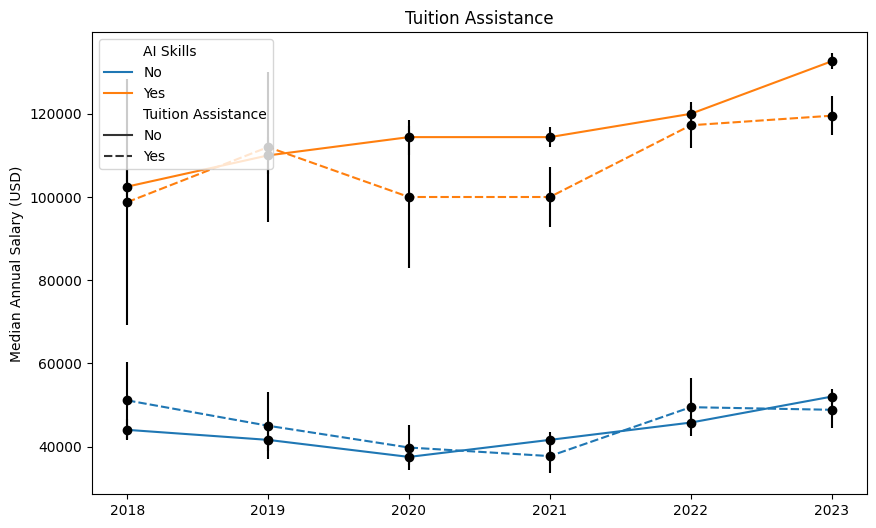

[<matplotlib.lines.Line2D object at 0x14ce27950>, <matplotlib.lines.Line2D object at 0x14ceb3260>, <matplotlib.lines.Line2D object at 0x14ceb0ce0>, <matplotlib.lines.Line2D object at 0x14ceb0440>, <matplotlib.lines.Line2D object at 0x14ceb3e00>, <matplotlib.lines.Line2D object at 0x14ceb07d0>] ['AI ROLE', 'False', 'True', 'PAID_LEAVE', 'False', 'True']


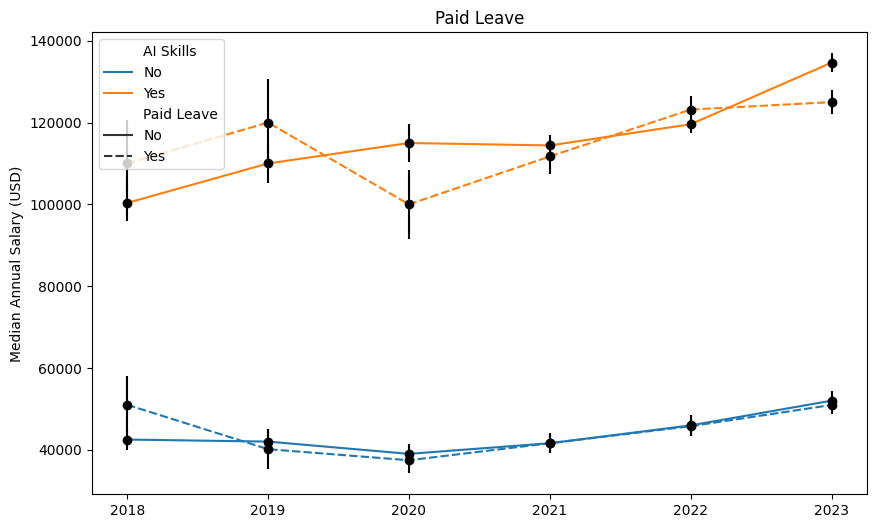

[<matplotlib.lines.Line2D object at 0x14ce0cf80>, <matplotlib.lines.Line2D object at 0x169c64ef0>, <matplotlib.lines.Line2D object at 0x169c67c80>, <matplotlib.lines.Line2D object at 0x169c67bf0>, <matplotlib.lines.Line2D object at 0x169c67a40>, <matplotlib.lines.Line2D object at 0x14ced5f40>] ['AI ROLE', 'False', 'True', 'HEALTH_WELLBEING', 'False', 'True']


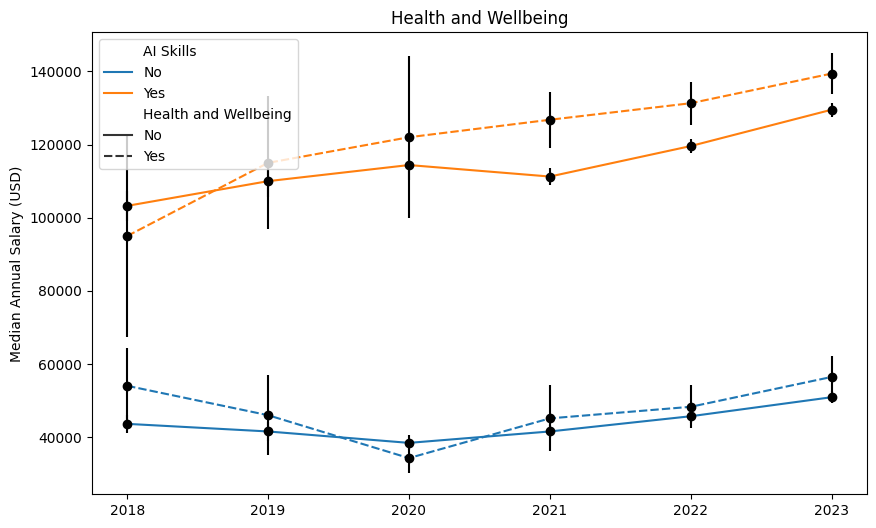

[<matplotlib.lines.Line2D object at 0x169c58920>, <matplotlib.lines.Line2D object at 0x169c581d0>, <matplotlib.lines.Line2D object at 0x169c583e0>, <matplotlib.lines.Line2D object at 0x169c58230>, <matplotlib.lines.Line2D object at 0x169c5a510>, <matplotlib.lines.Line2D object at 0x169c3c5c0>] ['AI ROLE', 'False', 'True', 'PARENTAL_LEAVE', 'False', 'True']


/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


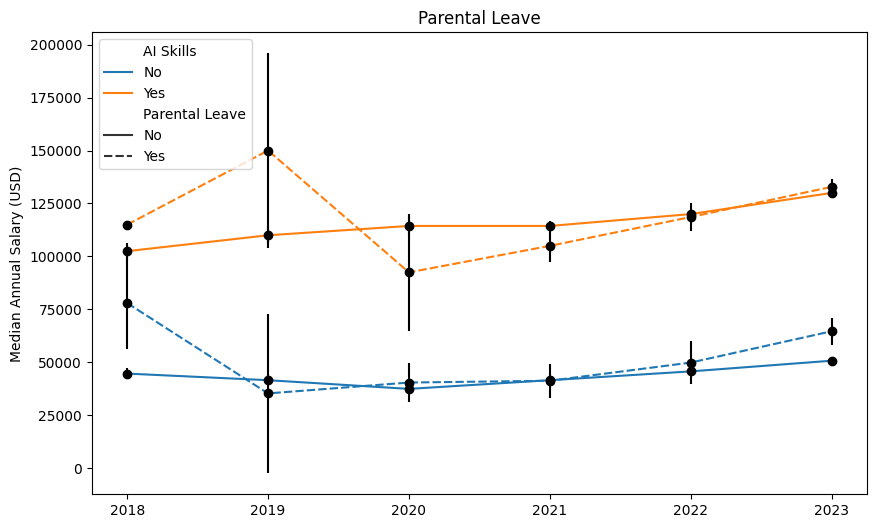

[<matplotlib.lines.Line2D object at 0x169c3d4c0>, <matplotlib.lines.Line2D object at 0x15ffe0830>, <matplotlib.lines.Line2D object at 0x320c95e50>, <matplotlib.lines.Line2D object at 0x320c962a0>, <matplotlib.lines.Line2D object at 0x320c96690>, <matplotlib.lines.Line2D object at 0x320c96840>] ['AI ROLE', 'False', 'True', 'CULTURE', 'False', 'True']


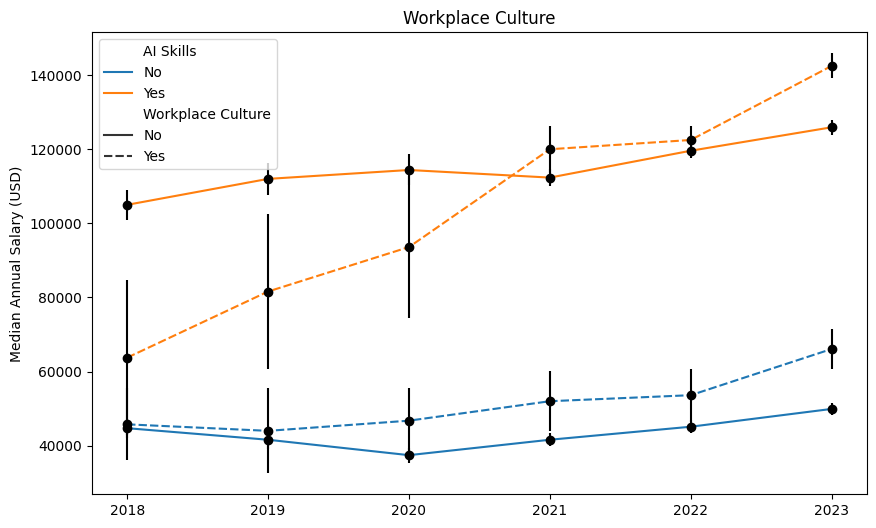

[<matplotlib.lines.Line2D object at 0x15ff50e00>, <matplotlib.lines.Line2D object at 0x15ff52300>, <matplotlib.lines.Line2D object at 0x15ff520f0>, <matplotlib.lines.Line2D object at 0x15ff51940>, <matplotlib.lines.Line2D object at 0x15ff53680>, <matplotlib.lines.Line2D object at 0x15ff501d0>] ['AI ROLE', 'False', 'True', 'wfh_wham', '0.0', '1.0']


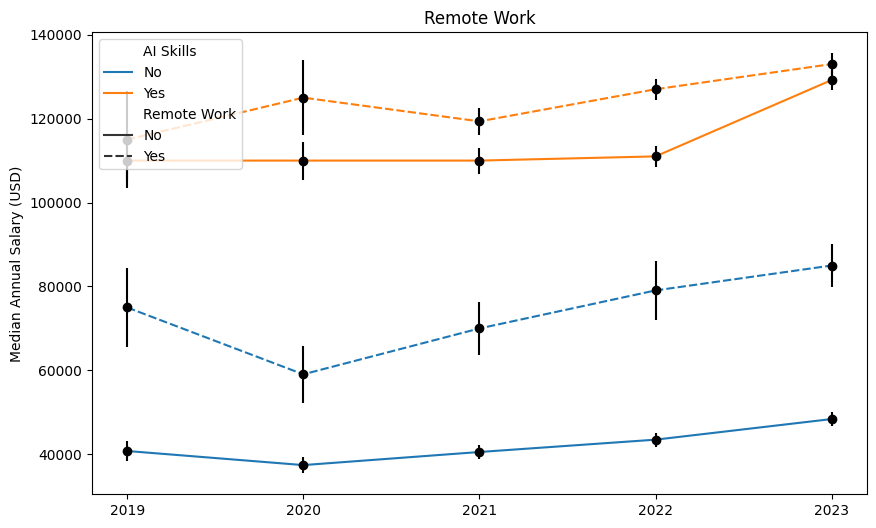

In [28]:
for benefit in benefits4:
    grouped_salary = usdf_salary.groupby(['YEAR', 'AI ROLE', benefit])['SALARY'].apply(
        lambda x: pd.Series(median_ci(x, confidence=0.95), index=['Median', 'CI_Lower', 'CI_Upper'])
    ).reset_index()
    # Convert the 'AI ROLE' and benefit to categorical if they are not already
    grouped_salary['AI ROLE'] = grouped_salary['AI ROLE'].astype(str)
    grouped_salary['SALARY'] = pd.to_numeric(grouped_salary['SALARY'], errors='coerce')
    grouped_salary['YEAR'] = grouped_salary['YEAR'].astype(int)

    grouped_salary[benefit] = grouped_salary[benefit].astype(str)

    median_data = grouped_salary[grouped_salary['level_3'] == 'Median']

    # Plotting
    plt.figure(figsize=(10, 6))

    # Use Seaborn's lineplot to plot the median salaries
    sns.lineplot(
        data=median_data,
        x='YEAR',
        y='SALARY',
        hue='AI ROLE',
        style=benefit,
        markers=False,
        errorbar=None
    )

    # Adding error bars manually
    for skill in median_data['AI ROLE'].unique():
        for remote in grouped_salary[benefit].unique():
            subset = grouped_salary[(grouped_salary['AI ROLE'] == skill) & (grouped_salary[benefit] == remote)]
            medians = subset[subset['level_3'] == 'Median']
            ci_lowers = subset[subset['level_3'] == 'CI_Lower']['SALARY'].astype(float).values
            ci_uppers = subset[subset['level_3'] == 'CI_Upper']['SALARY'].astype(float).values
            yerr = np.array([medians['SALARY'].values - ci_lowers, ci_uppers - medians['SALARY'].values])

            plt.errorbar(
                x=medians['YEAR'],
                y=medians['SALARY'],
                yerr=yerr,
                fmt='o',
                color='black'
            )

    plt.xticks(median_data['YEAR'].unique())
    # Customize the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    print(handles, labels)
    # Extract the relevant handles and labels
    new_handles = handles
    new_labels = ['AI Skills','No', 'Yes', f'{benefits_labels_map[benefit]}','No', 'Yes']
    plt.legend(handles=new_handles, labels=new_labels, loc = 'upper left')
    # set legend location
    # plt.legend(['','No AI Skills','AI Skills','','Not Remote','Remote'])
    # plt.legend(handles=handles[:4], labels=new_labels, title='Job Type and Remote Work')
    plt.xlabel(None)
    plt.ylabel('Median Annual Salary (USD)')
    plt.title(benefits_labels_map[benefit])
    # plt.title('Median Annual Salary by AI Skills and Remote Work with 95% Confidence Intervals')
    
    # if salary folder doesn't exist, create it
    if not os.path.exists('../figures/salary'):
        os.makedirs('../figures/salary')
    plt.savefig(f'../figures/salary/salary_by_{benefit}.png')

    plt.show()

# Updated Colors

In [12]:
usdf_salary['WLB'].dtype

dtype('bool')

[<matplotlib.lines.Line2D object at 0x7f975e267380>, <matplotlib.lines.Line2D object at 0x7f975e088e00>, <matplotlib.lines.Line2D object at 0x7f975e2679b0>, <matplotlib.lines.Line2D object at 0x7f975e267710>, <matplotlib.lines.Line2D object at 0x7f975e266270>, <matplotlib.lines.Line2D object at 0x7f975e266480>] ['AI ROLE', 'False', 'True', 'EDU_ASSISTANCE', 'False', 'True']


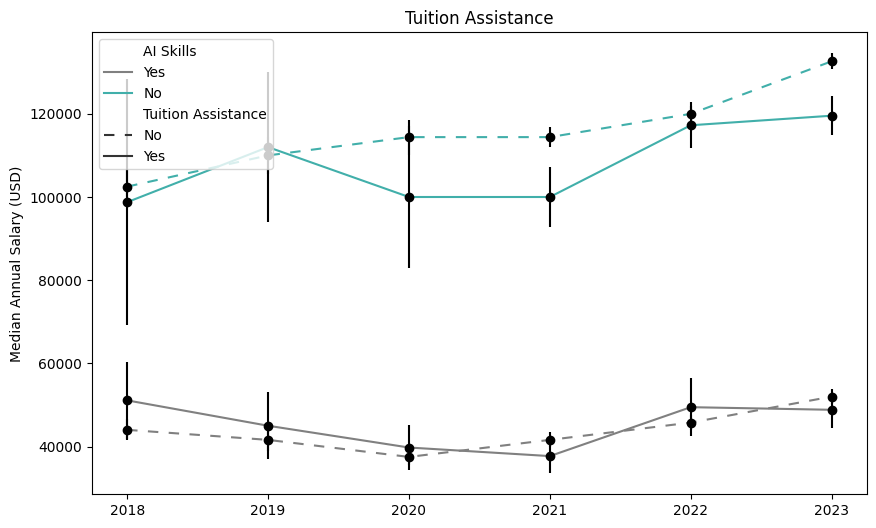

[<matplotlib.lines.Line2D object at 0x7f965520b1a0>, <matplotlib.lines.Line2D object at 0x7f965520b440>, <matplotlib.lines.Line2D object at 0x7f965520b680>, <matplotlib.lines.Line2D object at 0x7f965520b8c0>, <matplotlib.lines.Line2D object at 0x7f965520bb00>, <matplotlib.lines.Line2D object at 0x7f965520bd40>] ['AI ROLE', 'False', 'True', 'PAID_LEAVE', 'False', 'True']


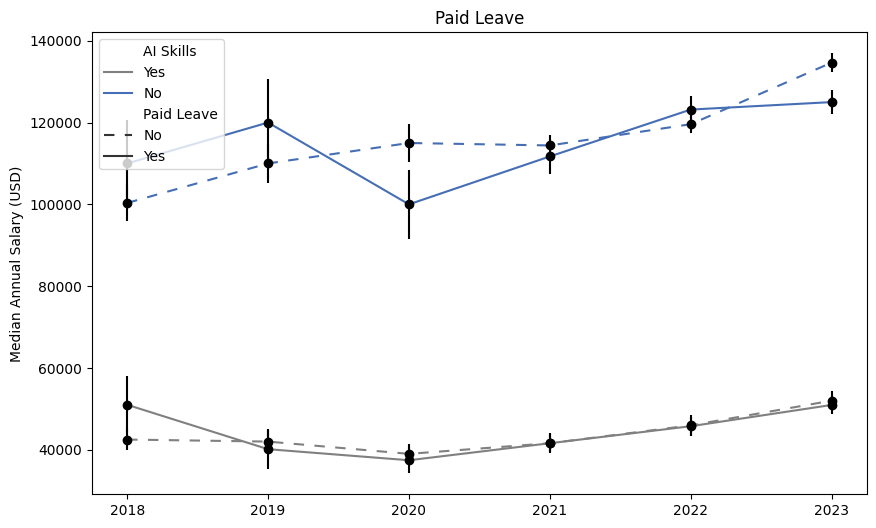

[<matplotlib.lines.Line2D object at 0x7f96552da570>, <matplotlib.lines.Line2D object at 0x7f96552da750>, <matplotlib.lines.Line2D object at 0x7f96552da990>, <matplotlib.lines.Line2D object at 0x7f96552daba0>, <matplotlib.lines.Line2D object at 0x7f96552bb9e0>, <matplotlib.lines.Line2D object at 0x7f96552b9ac0>] ['AI ROLE', 'False', 'True', 'HEALTH_WELLBEING', 'False', 'True']


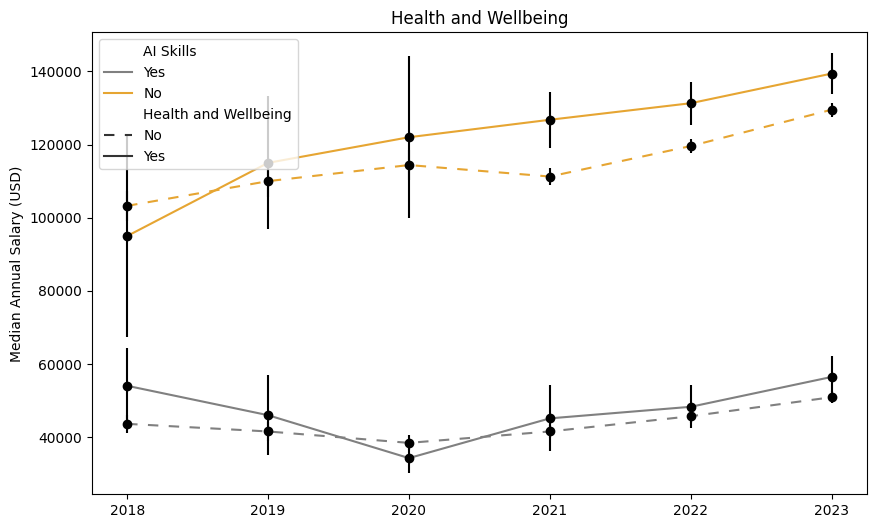

/data/sant6443/thesis/code/venv_thesis/lib/python3.12/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/data/sant6443/thesis/code/venv_thesis/lib/python3.12/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[<matplotlib.lines.Line2D object at 0x7f96551922a0>, <matplotlib.lines.Line2D object at 0x7f96551924b0>, <matplotlib.lines.Line2D object at 0x7f96551926f0>, <matplotlib.lines.Line2D object at 0x7f9655192930>, <matplotlib.lines.Line2D object at 0x7f965516ee70>, <matplotlib.lines.Line2D object at 0x7f9655192a20>] ['AI ROLE', 'False', 'True', 'PARENTAL_LEAVE', 'False', 'True']


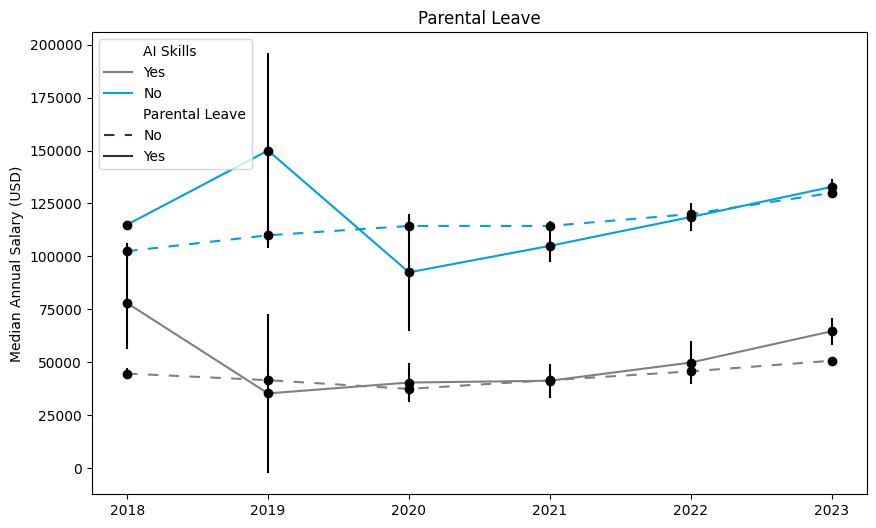

[<matplotlib.lines.Line2D object at 0x7f96550529f0>, <matplotlib.lines.Line2D object at 0x7f9655052c30>, <matplotlib.lines.Line2D object at 0x7f9655052e40>, <matplotlib.lines.Line2D object at 0x7f9655053080>, <matplotlib.lines.Line2D object at 0x7f96551f7bf0>, <matplotlib.lines.Line2D object at 0x7f9655033f80>] ['AI ROLE', 'False', 'True', 'CULTURE', 'False', 'True']


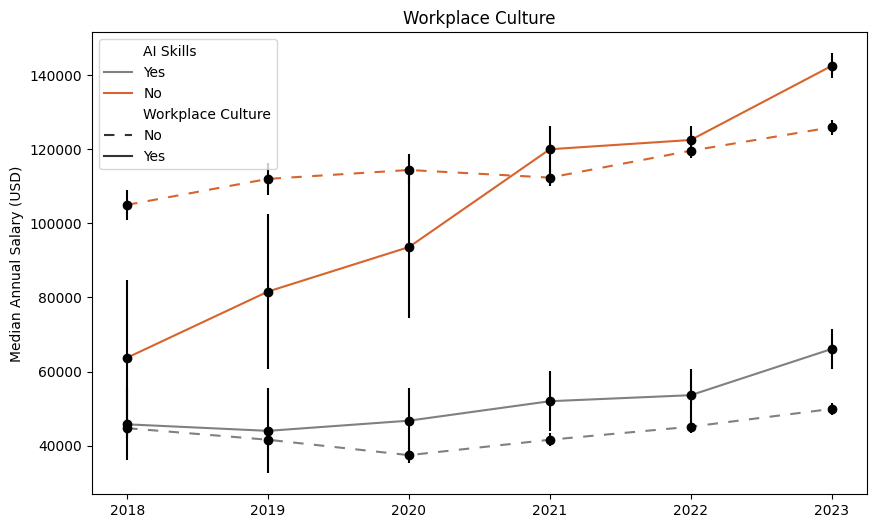

ValueError: These `dashes` levels are missing values: {'0.0', '1.0'}

<Figure size 1000x600 with 0 Axes>

In [18]:
for benefit in benefits4:
    palette = {'False': 'gray', 'True': benefit_colors[benefit]}
    style_mapping = {'False': (5,5), 'True': ''} 
    grouped_salary = usdf_salary.groupby(['YEAR', 'AI ROLE', benefit])['SALARY'].apply(
        lambda x: pd.Series(median_ci(x, confidence=0.95), index=['Median', 'CI_Lower', 'CI_Upper'])
    ).reset_index()
    # Convert the 'AI ROLE' and benefit to categorical if they are not already
    grouped_salary['AI ROLE'] = grouped_salary['AI ROLE'].astype(str)
    grouped_salary['SALARY'] = pd.to_numeric(grouped_salary['SALARY'], errors='coerce')
    grouped_salary['YEAR'] = grouped_salary['YEAR'].astype(int)

    grouped_salary[benefit] = grouped_salary[benefit].astype(str)

    median_data = grouped_salary[grouped_salary['level_3'] == 'Median']

    # Plotting
    plt.figure(figsize=(10, 6))

    # Use Seaborn's lineplot to plot the median salaries
    sns.lineplot(
        data=median_data,
        x='YEAR',
        y='SALARY',
        hue='AI ROLE',
        palette=palette,
        style=benefit,
        markers=False,
        errorbar=None, 
        dashes=style_mapping
    )

    # Adding error bars manually
    for skill in median_data['AI ROLE'].unique():
        for remote in grouped_salary[benefit].unique():
            subset = grouped_salary[(grouped_salary['AI ROLE'] == skill) & (grouped_salary[benefit] == remote)]
            medians = subset[subset['level_3'] == 'Median']
            ci_lowers = subset[subset['level_3'] == 'CI_Lower']['SALARY'].astype(float).values
            ci_uppers = subset[subset['level_3'] == 'CI_Upper']['SALARY'].astype(float).values
            yerr = np.array([medians['SALARY'].values - ci_lowers, ci_uppers - medians['SALARY'].values])

            plt.errorbar(
                x=medians['YEAR'],
                y=medians['SALARY'],
                yerr=yerr,
                fmt='o',
                color='black'
            )

    plt.xticks(median_data['YEAR'].unique())
    # Customize the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    print(handles, labels)
    # Extract the relevant handles and labels
    new_handles = handles
    new_labels = ['AI Skills','Yes', 'No', f'{benefits_labels_map[benefit]}','No', 'Yes']
    plt.legend(handles=new_handles, labels=new_labels, loc = 'upper left')
    # set legend location
    # plt.legend(['','No AI Skills','AI Skills','','Not Remote','Remote'])
    # plt.legend(handles=handles[:4], labels=new_labels, title='Job Type and Remote Work')
    plt.xlabel(None)
    plt.ylabel('Median Annual Salary (USD)')
    plt.title(benefits_labels_map[benefit])
    # plt.title('Median Annual Salary by AI Skills and Remote Work with 95% Confidence Intervals')
    
    # if salary folder doesn't exist, create it
    if not os.path.exists('../figures/salary'):
        os.makedirs('../figures/salary')
    # plt.savefig(f'../figures/salary/salary_by_{benefit}.png')

    plt.show()

In [17]:
for benefit in benefits4:
    palette = {'False': 'gray', 'True': benefit_colors[benefit]}
    
    grouped_salary = usdf_salary.groupby(['YEAR', 'AI ROLE', benefit])['SALARY'].apply(
        lambda x: pd.Series(median_ci(x, confidence=0.95), index=['Median', 'CI_Lower', 'CI_Upper'])
    ).reset_index()
    
    # Convert columns to appropriate data types
    grouped_salary['AI ROLE'] = grouped_salary['AI ROLE'].astype(str)
    grouped_salary['YEAR'] = grouped_salary['YEAR'].astype(int)
    grouped_salary[benefit] = grouped_salary[benefit].astype(str)

    median_data = grouped_salary[grouped_salary['level_3'] == 'Median']

    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot without specifying dashes to avoid the TypeError
    sns.lineplot(
        data=median_data,
        x='YEAR',
        y='SALARY',
        hue='AI ROLE',
        palette=palette,
        style=benefit,
        markers=False,
        errorbar=None
    )

    # Update line styles based on benefit status
    for line, benefit_value in zip(plt.gca().get_lines(), median_data[benefit]):
        line.set_linestyle('-' if benefit_value == 'True' else '--')  # Solid for True, dashed for False

    # Adding error bars manually
    for skill in median_data['AI ROLE'].unique():
        for remote in grouped_salary[benefit].unique():
            subset = grouped_salary[(grouped_salary['AI ROLE'] == skill) & (grouped_salary[benefit] == remote)]
            medians = subset[subset['level_3'] == 'Median']
            ci_lowers = subset[subset['level_3'] == 'CI_Lower']['SALARY'].astype(float).values
            ci_uppers = subset[subset['level_3'] == 'CI_Upper']['SALARY'].astype(float).values
            yerr = np.array([medians['SALARY'].values - ci_lowers, ci_uppers - medians['SALARY'].values])

            plt.errorbar(
                x=medians['YEAR'],
                y=medians['SALARY'],
                yerr=yerr,
                fmt='o',
                color='black'
            )

    plt.xticks(median_data['YEAR'].unique())

    # Customize the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = ['AI Skills', 'No', 'Yes', f'{benefits_labels_map[benefit]}', 'No', 'Yes']
    plt.legend(handles=handles[:6], labels=new_labels, loc='upper left')

    plt.xlabel(None)
    plt.ylabel('Median Annual Salary (USD)')
    plt.title(benefits_labels_map[benefit])

    # Save the plot
    if not os.path.exists('../figures/salary'):
        os.makedirs('../figures/salary')
    plt.show()


ValueError: At least one value in the dash list must be positive

<Figure size 1000x600 with 1 Axes>

ValueError: At least one value in the dash list must be positive

<Figure size 1000x600 with 1 Axes>

ValueError: At least one value in the dash list must be positive

...

<Figure size 1000x600 with 1 Axes>

ValueError: At least one value in the dash list must be positive

<Figure size 1000x600 with 1 Axes>

ValueError: At least one value in the dash list must be positive

<Figure size 1000x600 with 1 Axes>

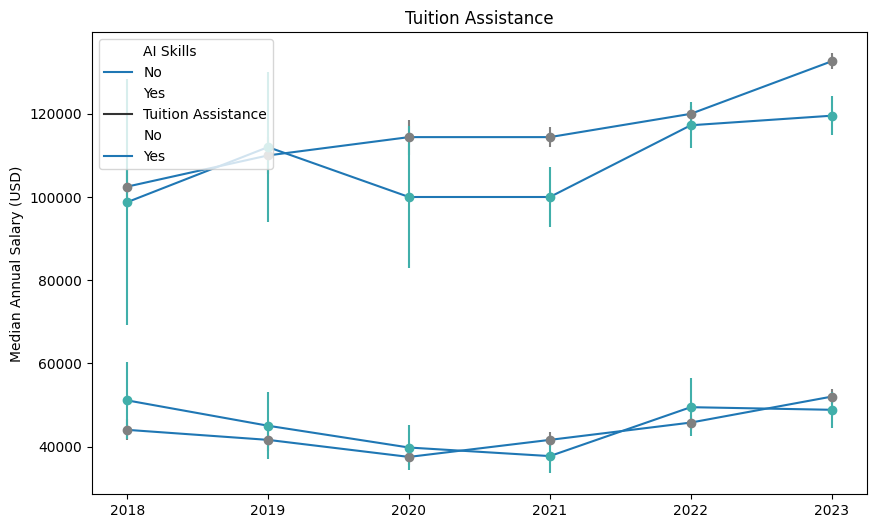

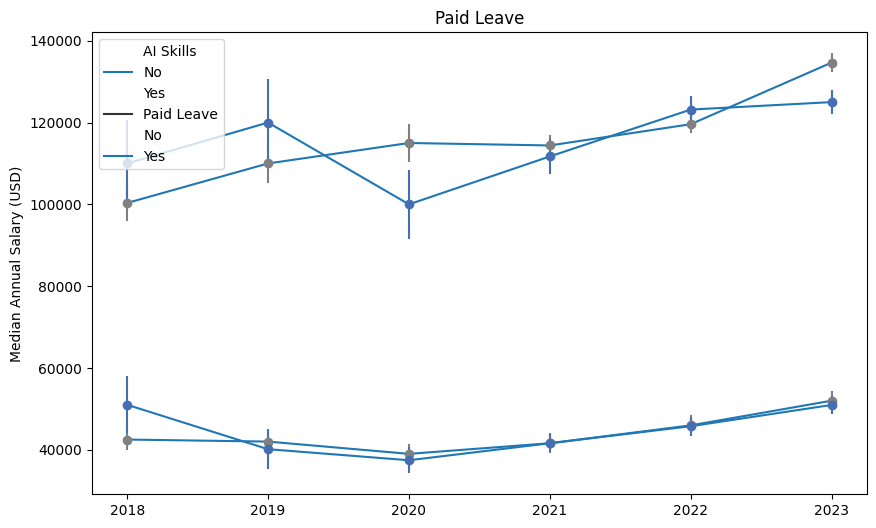

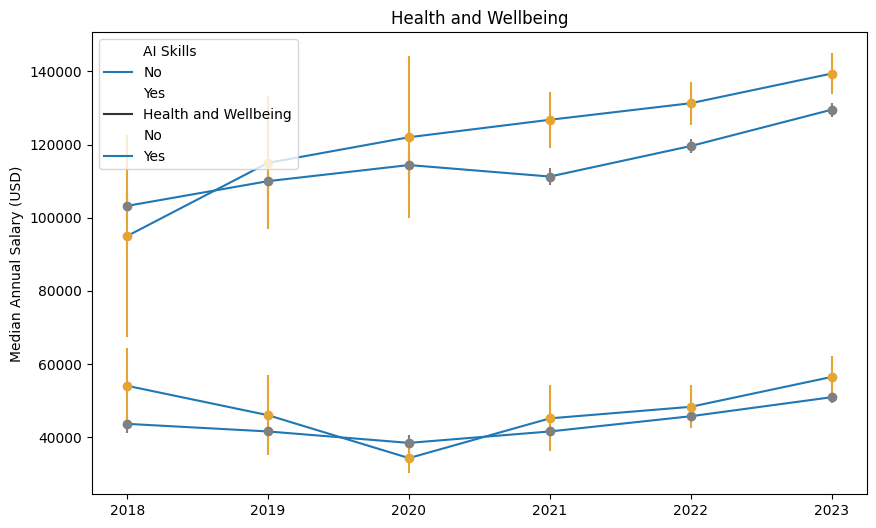

/data/sant6443/thesis/code/venv_thesis/lib/python3.12/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/data/sant6443/thesis/code/venv_thesis/lib/python3.12/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


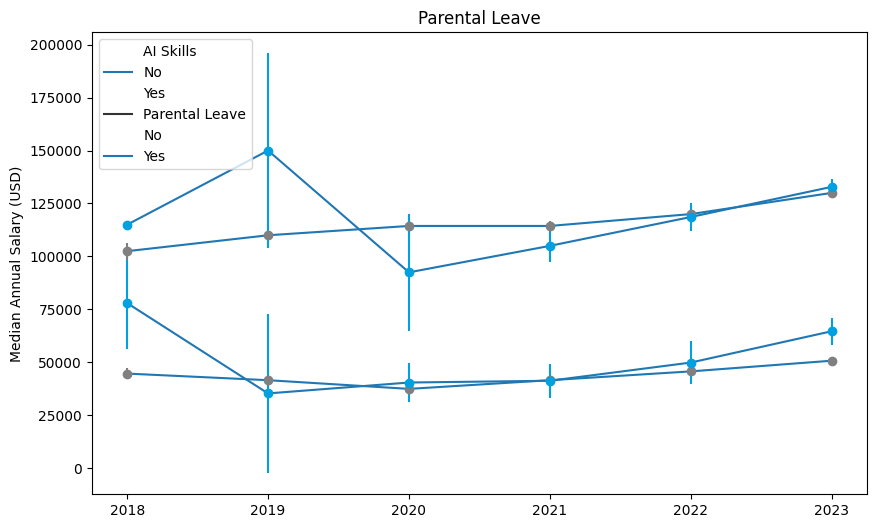

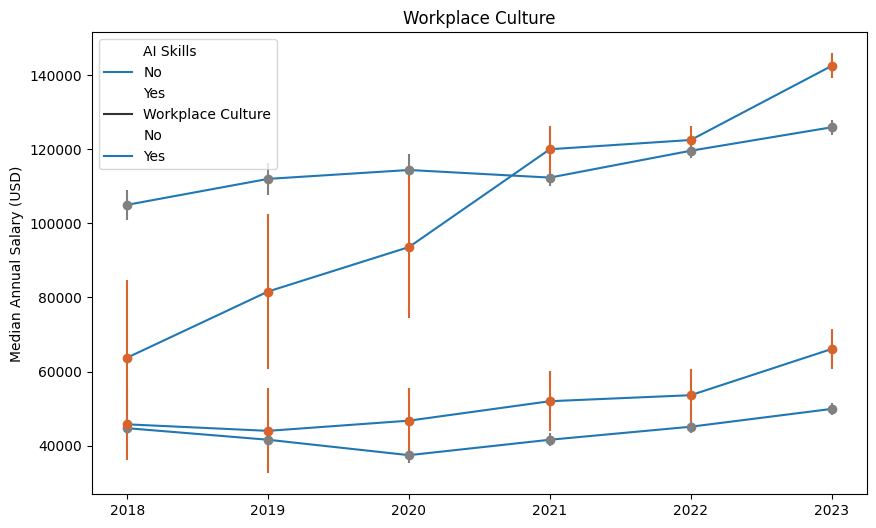

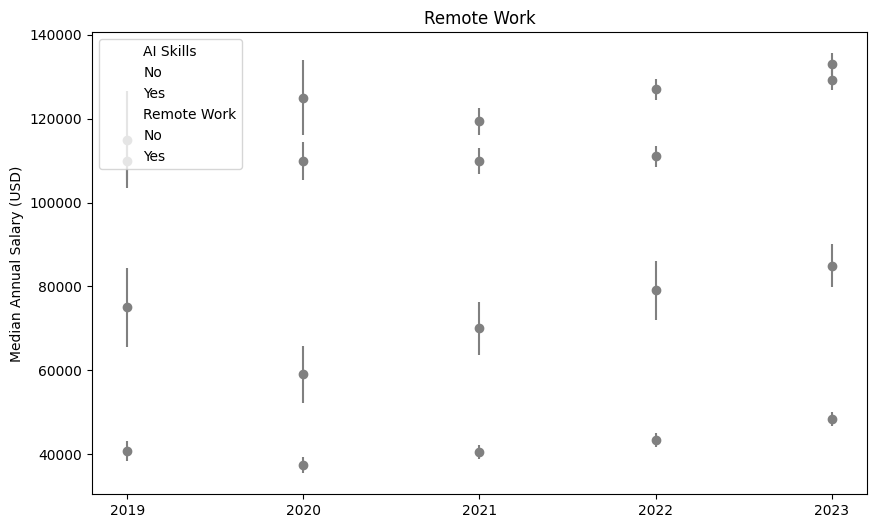

In [7]:
for benefit in benefits4:
    grouped_salary = usdf_salary.groupby(['YEAR', 'AI ROLE', benefit])['SALARY'].apply(
        lambda x: pd.Series(median_ci(x, confidence=0.95), index=['Median', 'CI_Lower', 'CI_Upper'])
    ).reset_index()
    
    palette = {''}
    # Convert the 'AI ROLE' and benefit to categorical if they are not already
    grouped_salary['AI ROLE'] = grouped_salary['AI ROLE'].astype(bool)  # Ensure AI ROLE is boolean
    grouped_salary['YEAR'] = grouped_salary['YEAR'].astype(int)
    grouped_salary[benefit] = grouped_salary[benefit].astype(str)

    median_data = grouped_salary[grouped_salary['level_3'] == 'Median']
    
    # Plotting
    plt.figure(figsize=(10, 6))

    for role in [True, False]:
        for benefit_status in ['True', 'False']:
            subset = median_data[(median_data['AI ROLE'] == role) & (median_data[benefit] == benefit_status)]
            
            # Determine line color: benefit's color for True, gray for False
            line_color = benefit_colors[benefit] if benefit_status == 'True' else 'gray'
            sns.lineplot(
                data=subset,
                x='YEAR',
                y='SALARY',
                hue='AI ROLE',
                style=benefit,
                color=line_color,
                errorbar=None
            )
    
    # Adding error bars manually
    for skill in median_data['AI ROLE'].unique():
        for remote in grouped_salary[benefit].unique():
            subset = grouped_salary[(grouped_salary['AI ROLE'] == skill) & (grouped_salary[benefit] == remote)]
            medians = subset[subset['level_3'] == 'Median']
            ci_lowers = subset[subset['level_3'] == 'CI_Lower']['SALARY'].astype(float).values
            ci_uppers = subset[subset['level_3'] == 'CI_Upper']['SALARY'].astype(float).values
            yerr = np.array([medians['SALARY'].values - ci_lowers, ci_uppers - medians['SALARY'].values])

            # Set color for error bars based on AI ROLE and benefit status
            error_color = benefit_colors[benefit] if remote == 'True' else 'gray'
            plt.errorbar(
                x=medians['YEAR'],
                y=medians['SALARY'],
                yerr=yerr,
                fmt='o',
                color=error_color
            )

    plt.xticks(median_data['YEAR'].unique())

    # Customize the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = ['AI Skills','No', 'Yes', f'{benefits_labels_map[benefit]}', 'No', 'Yes']
    plt.legend(handles=handles[:6], labels=new_labels, loc='upper left')

    plt.xlabel(None)
    plt.ylabel('Median Annual Salary (USD)')
    plt.title(benefits_labels_map[benefit])

    # Save the plot
    if not os.path.exists('../figures/salary'):
        os.makedirs('../figures/salary')
    # plt.savefig(f'../figures/salary/salary_by_{benefit}.png')
    plt.show()
